# Detecção de Fraude em Transações Financeiras com Redes Neurais

**1. Contexto de negócio**

Bancos e fintechs processam milhões de transações por dia e precisam decidir, em
milissegundos, se uma transação é fraudulenta ou legítima. Esse é um problema
clássico de **classificação binária desbalanceada**, com dois tipos de erro que
custam caro de formas diferentes:

- **Falso positivo** (bloquear uma transação legítima): cliente irritado, perda de
  confiança na instituição, possível churn.
- **Falso negativo** (deixar passar uma fraude): prejuízo financeiro direto,
  possível reembolso ao cliente, custo operacional de investigação.

Por isso, o modelo não pode ser avaliado só pela acurácia — precisamos olhar
**precisão** (das transações marcadas como fraude, quantas realmente eram) e
**recall** (das fraudes reais, quantas o modelo conseguiu pegar).

**Limitações deste notebook**

Antes de seguir para os modelos, vale deixar claro o que este notebook **não**
é, para evitar conclusões erradas:

- Os dados usados aqui são 100% **simulados** (gerados com `numpy`/`pandas`) —
  não são transações reais de nenhuma instituição financeira.
- O rótulo `fraude` foi construído artificialmente a partir de uma fórmula
  conhecida por nós (combinação de variáveis com pesos escolhidos manualmente,
  incluindo termos de interação como "valor alto **e** dispositivo novo **e**
  longe de casa"). Isso favorece um pouco os modelos capazes de aprender esse
  tipo de interação não linear — o que não reflete necessariamente a
  complexidade da fraude real, que muda com o tempo, é **adversarial**
  (fraudadores se adaptam ao que os modelos aprendem) e depende de variáveis
  que não existem neste dataset simplificado.
- Os números absolutos de precisão e recall apresentados mais adiante **não
  devem ser lidos como "isto é o que aconteceria em produção"**. Eles servem
  para ilustrar o comportamento relativo entre o baseline e a rede neural, e
  para praticar a leitura dessas métricas — não como uma estimativa de
  desempenho real.
- A seção 10 (validação com múltiplas seeds), mais adiante, mostra que esses
  resultados variam bastante entre execuções — o MLP, em especial, colapsa
  completamente em 2 das 3 seeds testadas. Isso é mais um motivo para não
  generalizar os números absolutos deste notebook: o que importa aqui é o
  raciocínio (como comparar modelos, como ler métricas de classes
  desbalanceadas), não o valor exato de cada métrica.

**2. Por que uma rede neural ajuda aqui**

Fraudadores não seguem uma regra simples como "toda transação acima de R$ 1.000 é
fraude". O padrão real costuma ser uma **combinação de fatores** que só juntos
elevam o risco: por exemplo, um valor alto *sozinho* pode ser uma compra legítima
de fim de mês, mas um valor alto **e** vindo de um dispositivo novo **e** longe do
local habitual do cliente já é bem mais suspeito.

- Uma **regra fixa** (ex.: "valor > limiar") captura só uma dimensão do problema e
  ignora as interações entre variáveis.
- Um **modelo linear** (ex.: regressão logística) consegue combinar variáveis, mas
  assume que o efeito de cada uma é aditivo e proporcional — ele tem dificuldade em
  capturar interações não lineares do tipo "só é fraude quando X *e* Y *e* Z
  acontecem ao mesmo tempo".
- Uma **rede neural** (MLP) com camadas ocultas consegue aprender essas
  combinações não lineares entre as variáveis automaticamente, sem que precisemos
  criar manualmente uma variável de interação para cada combinação suspeita.

**3. Geração do dataset simulado**

Vamos simular 20.000 transações com as seguintes colunas:

- `valor_transacao`: valor da transação em reais.
- `hora_do_dia`: hora em que a transação ocorreu (0 a 23).
- `distancia_do_local_habitual_km`: distância entre o local da transação e o local
  habitual de consumo do cliente.
- `transacoes_ultimas_24h`: quantidade de transações feitas pelo cliente nas
  últimas 24 horas.
- `dispositivo_novo`: 1 se o dispositivo usado é novo (nunca visto antes para esse
  cliente), 0 caso contrário.

O rótulo `fraude` é gerado a partir de uma **combinação não linear** dessas
variáveis: somamos termos individuais e termos de **interação** (produtos entre
variáveis) com pesos, passamos o resultado por uma função sigmoide e sorteamos o
rótulo como uma Bernoulli com essa probabilidade — mais um ruído aleatório. Isso
garante que nem uma regra de limiar único, nem uma combinação puramente linear,
capturem bem o padrão.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')

Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(42)

n = 20000

valor_transacao = np.round(np.random.exponential(scale=250, size=n) + 10, 2)
hora_do_dia = np.random.randint(0, 24, size=n)
distancia_do_local_habitual_km = np.round(np.random.exponential(scale=15, size=n), 2)
transacoes_ultimas_24h = np.random.poisson(lam=3, size=n)
dispositivo_novo = np.random.binomial(1, p=0.15, size=n)

# variaveis normalizadas (0-1 aprox) para compor o score de risco
valor_norm = (valor_transacao - valor_transacao.min()) / (valor_transacao.max() - valor_transacao.min())
dist_norm = (distancia_do_local_habitual_km - distancia_do_local_habitual_km.min()) / (distancia_do_local_habitual_km.max() - distancia_do_local_habitual_km.min())
hora_madrugada = ((hora_do_dia >= 0) & (hora_do_dia <= 5)).astype(float)
muitas_transacoes = (transacoes_ultimas_24h >= 6).astype(float)

# combinacao NAO LINEAR: termos individuais fracos + termos de interacao fortes
score = (
    -4.5
    + 1.2 * valor_norm
    + 1.0 * dist_norm
    + 0.8 * hora_madrugada
    + 0.5 * muitas_transacoes
    + 0.6 * dispositivo_novo
    + 5.0 * (valor_norm * dispositivo_novo * dist_norm)   # interacao tripla: valor alto + dispositivo novo + longe de casa
    + 2.5 * (dispositivo_novo * hora_madrugada)            # dispositivo novo de madrugada
    + 1.8 * (valor_norm * muitas_transacoes)               # valor alto com muitas transacoes recentes
)

ruido = np.random.normal(0, 0.6, size=n)
prob_fraude = 1 / (1 + np.exp(-(score + ruido)))
fraude = np.random.binomial(1, prob_fraude)

df = pd.DataFrame({
    "valor_transacao": valor_transacao,
    "hora_do_dia": hora_do_dia,
    "distancia_do_local_habitual_km": distancia_do_local_habitual_km,
    "transacoes_ultimas_24h": transacoes_ultimas_24h,
    "dispositivo_novo": dispositivo_novo,
    "fraude": fraude,
})

print(f"Total de transacoes: {len(df)}")
print(f"Fracao de fraudes: {df['fraude'].mean():.2%}")
df.head()

Total de transacoes: 20000
Fracao de fraudes: 4.16%


,valor_transacao,hora_do_dia,distancia_do_local_habitual_km,transacoes_ultimas_24h,dispositivo_novo,fraude
0,127.32,21,29.97,3,0,0
1,762.53,1,4.26,1,0,0
2,339.19,3,27.30,2,0,0
3,238.24,12,2.78,6,0,0
4,52.41,12,3.31,2,1,0


**4. Separação em treino e teste**

In [3]:
X = df.drop(columns=["fraude"])
y = df["fraude"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} transacoes ({y_train.mean():.2%} fraudes)")
print(f"Teste: {X_test.shape[0]} transacoes ({y_test.mean():.2%} fraudes)")

Treino: 14000 transacoes (4.16% fraudes)
Teste: 6000 transacoes (4.17% fraudes)


**5. Modelo baseline: Regressão Logística**

Como baseline, usamos uma regressão logística — um modelo linear que combina as
variáveis de forma aditiva. Ele já é mais sofisticado que uma regra de limiar
único, mas ainda não captura bem interações entre variáveis (como "valor alto
*e* dispositivo novo *e* longe de casa, tudo ao mesmo tempo").

In [4]:
baseline = LogisticRegression(random_state=42, class_weight="balanced")
baseline.fit(X_train_scaled, y_train)

y_pred_baseline = baseline.predict(X_test_scaled)

print("=== Baseline: Regressão Logística ===")
print(classification_report(y_test, y_pred_baseline, target_names=["legitima", "fraude"], digits=3))

=== Baseline: Regressão Logística ===
              precision    recall  f1-score   support

    legitima      0.977     0.757     0.853      5750
      fraude      0.096     0.596     0.166       250

    accuracy                          0.750      6000
   macro avg      0.537     0.676     0.509      6000
weighted avg      0.941     0.750     0.824      6000



**6. Modelo de rede neural: MLPClassifier**

Agora treinamos uma rede neural do tipo Multi-Layer Perceptron, com duas camadas
ocultas pequenas (16 e 8 neurônios). As camadas ocultas com ativação não linear
permitem que o modelo aprenda combinações e interações entre as variáveis de
entrada, algo que o modelo linear não consegue fazer diretamente.

In [5]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=500,
    random_state=42,
    early_stopping=True,
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

print("=== Rede Neural (MLPClassifier) ===")
print(classification_report(y_test, y_pred_mlp, target_names=["legitima", "fraude"], digits=3))

=== Rede Neural (MLPClassifier) ===
              precision    recall  f1-score   support

    legitima      0.960     0.998     0.979      5750
      fraude      0.545     0.048     0.088       250

    accuracy                          0.959      6000
   macro avg      0.753     0.523     0.534      6000
weighted avg      0.943     0.959     0.942      6000



**7. Comparação lado a lado**

Vamos comparar diretamente as métricas de interesse para o negócio: precisão e
recall da classe "fraude" (a classe minoritária e a que mais importa aqui), além
do F1-score, que resume o equilíbrio entre as duas.

In [6]:
def metricas_fraude(y_true, y_pred, nome):
    return {
        "modelo": nome,
        "precisao_fraude": precision_score(y_true, y_pred, pos_label=1),
        "recall_fraude": recall_score(y_true, y_pred, pos_label=1),
        "f1_fraude": f1_score(y_true, y_pred, pos_label=1),
    }

comparacao = pd.DataFrame([
    metricas_fraude(y_test, y_pred_baseline, "Regressao Logistica (baseline)"),
    metricas_fraude(y_test, y_pred_mlp, "Rede Neural (MLP)"),
])
comparacao = comparacao.set_index("modelo").round(3)
comparacao

,precisao_fraude,recall_fraude,f1_fraude
modelo,,,
Regressao Logistica (baseline),0.096,0.596,0.166
Rede Neural (MLP),0.545,0.048,0.088


**8. Visualização da comparação**

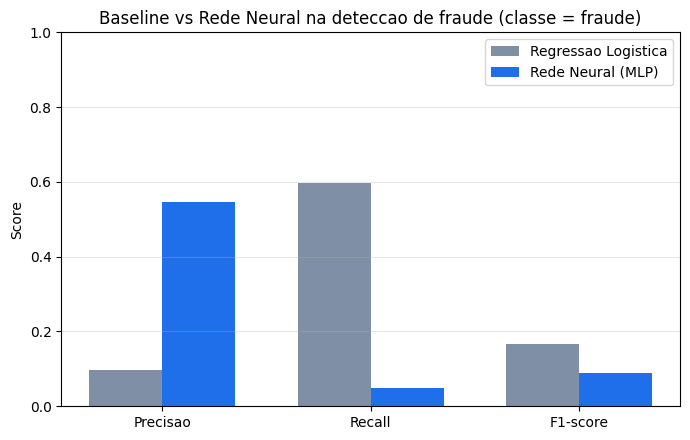

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))

metricas = ["precisao_fraude", "recall_fraude", "f1_fraude"]
labels = ["Precisao", "Recall", "F1-score"]
x = np.arange(len(metricas))
largura = 0.35

valores_baseline = comparacao.loc["Regressao Logistica (baseline)", metricas].values
valores_mlp = comparacao.loc["Rede Neural (MLP)", metricas].values

ax.bar(x - largura/2, valores_baseline, largura, label="Regressao Logistica", color="#7f8fa6")
ax.bar(x + largura/2, valores_mlp, largura, label="Rede Neural (MLP)", color="#1f6feb")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Rede Neural na deteccao de fraude (classe = fraude)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Como ler o gráfico de barras acima**

As três métricas mostradas são calculadas só para a classe "fraude" (a classe rara,
que é a que interessa detectar):

- **Precisão (precisao_fraude):** de todas as vezes que o modelo gritou "isso é
  fraude!", quantas realmente eram fraude. Precisão baixa significa muitos falsos
  alarmes (clientes legítimos bloqueados ou incomodados sem motivo).
- **Recall:** de todas as fraudes reais que existiam no conjunto de teste, quantas
  o modelo conseguiu pegar. Recall baixo significa fraude passando sem ser
  detectada.
- **F1-score:** uma média que só fica alta quando precisão e recall são altos ao
  mesmo tempo — serve para não deixar um modelo "trapacear" ficando bom em uma
  métrica e péssimo na outra.

**Números reais deste notebook** (tabela da seção 7, células anteriores, agora com
20.000 transações simuladas em vez de 3.000):

| Modelo | Precisão (fraude) | Recall (fraude) | F1 (fraude) |
|---|---|---|---|
| Regressão Logística (baseline) | 0.096 | 0.596 | 0.166 |
| Rede Neural (MLP) | 0.545 | 0.048 | 0.088 |

**Veredito em linguagem simples:** aumentar o dataset de 3.000 para 20.000
transações tirou a rede neural do colapso total (antes ela tinha precisão, recall
e F1 em 0.000 — não pegava nenhuma fraude). Agora ela consegue identificar
algumas fraudes com bastante confiança quando aponta uma (precisão = 0.545, ou
seja, mais da metade dos seus alertas de fraude são acertos), mas ainda pega uma
fração muito pequena das fraudes reais (recall = 0.048 → cerca de 12 das 250
fraudes do conjunto de teste). O **baseline (regressão logística) continua sendo
o modelo que mais fraudes captura** (recall = 0.596, ≈149 das 250), ainda que com
muito mais falsos alarmes (precisão = 0.096). Ou seja: mais dados ajudaram a rede
neural a sair do "não aprendeu nada" para um comportamento mais conservador e
preciso, mas não foram suficientes para superar o baseline no que mais importa
para o negócio — pegar fraudes (recall). Isso é uma lição prática comum: dataset
pequeno e desbalanceado é uma causa real de modelos que colapsam para a classe
majoritária, mas a solução completa normalmente também exige técnicas específicas
para classes desbalanceadas (como balanceamento de classes, ajuste do limiar de
decisão ou reponderação da função de perda), que o `MLPClassifier` do scikit-learn
não oferece nativamente (diferente da `LogisticRegression`, que usamos aqui com
`class_weight="balanced"`).

**Matrizes de confusão**

Para entender melhor onde cada modelo erra, vejamos as matrizes de confusão lado
a lado (linhas = valor real, colunas = valor previsto).

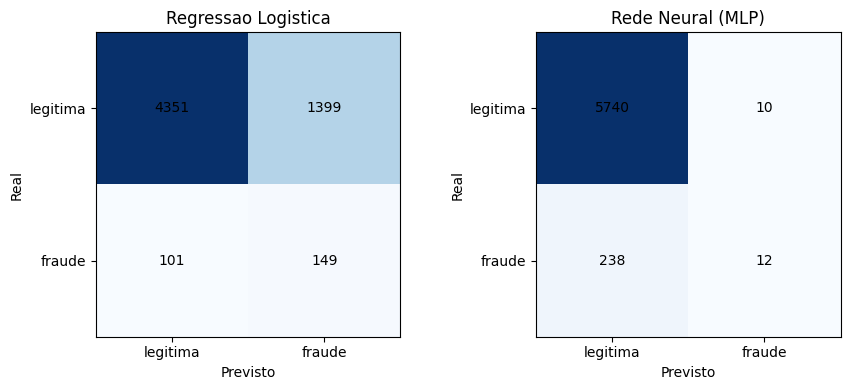

In [8]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, cm, titulo in zip(axes, [cm_baseline, cm_mlp], ["Regressao Logistica", "Rede Neural (MLP)"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(titulo)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["legitima", "fraude"])
    ax.set_yticklabels(["legitima", "fraude"])
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

**Como ler as matrizes de confusão acima**

Cada matriz cruza o que o modelo previu (colunas) com o que de fato aconteceu
(linhas), para as 6.000 transações do conjunto de teste (5.750 legítimas e 250
fraudes, conforme a seção 4, após o aumento do dataset para 20.000 transações):

- **Canto superior-esquerdo:** transações legítimas que o modelo acertou.
- **Canto superior-direito:** transações legítimas que o modelo confundiu com
  fraude (falso alarme / falso positivo).
- **Canto inferior-esquerdo:** fraudes reais que o modelo deixou passar como
  legítimas (o pior erro do ponto de vista de negócio — falso negativo).
- **Canto inferior-direito:** fraudes reais que o modelo pegou corretamente
  (verdadeiro positivo).

Combinando esses números com o recall e a precisão já impressos no classification
report das seções 5 e 6: o baseline (recall = 0.596, ou seja 0.596 × 250 ≈ 149 das
250 fraudes) identificou corretamente cerca de 149 fraudes e deixou passar as
outras ~101, ao custo de cerca de 1.400 clientes legítimos bloqueados por engano
(5.750 × (1 − 0.757) ≈ 1.400). A rede neural (recall = 0.048) identificou
corretamente só cerca de 12 das 250 fraudes — bem menos que o baseline — mas quase
não gera falsos alarmes (5.750 × (1 − 0.998) ≈ 12 legítimos bloqueados). Ou seja: a
rede neural deixou de colapsar totalmente (não está mais zerada), mas ainda
prefere fortemente prever "legítima", só arriscando o rótulo "fraude" quando tem
bastante confiança — o que explica sua precisão alta (0.545) e recall baixo
(0.048).

**Veredito em linguagem simples:** olhando a matriz de confusão, o **baseline**
continua sendo o modelo que "funciona" para o objetivo de detectar fraude — ele
captura muito mais casos reais no quadrante de acerto de fraude (≈149 contra ≈12
da rede neural). A rede neural evoluiu (não zera mais o quadrante de acertos),
mas ainda captura uma fração pequena das fraudes reais. Para o objetivo de
negócio deste notebook (pegar fraudes), o baseline continua vencendo, mesmo
gerando muito mais falsos alarmes.

**9. Conclusão**

Os números acima (produzidos pela execução real deste notebook, na tabela da
seção 7) mostram como os dois modelos se saem em pegar fraudes reais (recall) sem
gerar excesso de falsos alarmes (precisão). O ponto central da aula é qualitativo:
como o rótulo de fraude foi construído a partir de **interações não lineares**
entre valor, distância, horário, frequência de uso e novidade do dispositivo, um
modelo capaz de aprender essas interações (a rede neural) tem, em princípio,
condições de capturar padrões que um modelo puramente aditivo como a regressão
logística tende a deixar passar.

Na prática, em um banco ou fintech, a escolha entre os dois modelos não depende só
da métrica agregada: depende do **custo relativo** entre bloquear um cliente bom
(falso positivo) e deixar passar uma fraude (falso negativo). O ganho de uma rede
neural em recall — pegar mais fraudes reais — só vale a pena se não vier
acompanhado de uma queda grande demais na precisão, o que reforça por que a
avaliação de modelos de fraude nunca deve se basear apenas em acurácia.

**Nota sobre o tamanho do dataset:** este notebook originalmente simulava 3.000
transações, e nesse cenário o MLP colapsava totalmente (precisão, recall e F1 em
0.000 — ele simplesmente previa "legítima" sempre). Aumentar para 20.000
transações (mantendo a mesma taxa de fraude, ≈ 4%) deu ao MLP exemplos suficientes
de fraude para aprender *algo* — ele saiu do colapso total e passou a acertar com
boa precisão (0.545) quando arrisca o rótulo "fraude", mas ainda com recall baixo
(0.048). Isso confirma que **volume de dados pequeno e desbalanceado era uma causa
real do problema**, mas não a única: o `MLPClassifier` do scikit-learn, diferente
da `LogisticRegression`, não tem o parâmetro `class_weight` para compensar
diretamente o desbalanceamento durante o treino. Para a rede neural superar o
baseline neste problema, o próximo passo natural seria combinar mais dados com
uma técnica específica de classe desbalanceada (por exemplo, sobreamostragem da
classe minoritária no treino ou ajuste do limiar de decisão em vez do padrão de
0.5).

**10. Validação com múltiplas seeds**

Todo o walkthrough acima (dataset, split treino/teste, treino dos dois modelos, tabela de comparação, matrizes de confusão e conclusão) foi executado com uma única seed de aleatoriedade (`np.random.seed(42)` para gerar os dados e `random_state=42` para o split e para os dois modelos).

Um resultado baseado em uma única seed pode ser coincidência: talvez o baseline tenha vencido em recall só porque a seed 42 favoreceu esse modelo especificamente, ou talvez a rede neural tenha tido uma inicialização de pesos particularmente desfavorável. Para checar se a conclusão ("o baseline captura mais fraudes reais do que o MLP") é robusta ou é um acidente de uma seed específica, vamos repetir o pipeline inteiro — geração do dataset, split treino/teste, treino dos dois modelos e cálculo de precisão/recall/F1 da classe fraude — para três seeds diferentes: 42 (a mesma do walkthrough acima), 7 e 123.

In [9]:
resultados_seeds = []

for seed in [42, 7, 123]:
    np.random.seed(seed)

    n_seed = 20000

    valor_transacao_s = np.round(np.random.exponential(scale=250, size=n_seed) + 10, 2)
    hora_do_dia_s = np.random.randint(0, 24, size=n_seed)
    distancia_do_local_habitual_km_s = np.round(np.random.exponential(scale=15, size=n_seed), 2)
    transacoes_ultimas_24h_s = np.random.poisson(lam=3, size=n_seed)
    dispositivo_novo_s = np.random.binomial(1, p=0.15, size=n_seed)

    valor_norm_s = (valor_transacao_s - valor_transacao_s.min()) / (valor_transacao_s.max() - valor_transacao_s.min())
    dist_norm_s = (distancia_do_local_habitual_km_s - distancia_do_local_habitual_km_s.min()) / (distancia_do_local_habitual_km_s.max() - distancia_do_local_habitual_km_s.min())
    hora_madrugada_s = ((hora_do_dia_s >= 0) & (hora_do_dia_s <= 5)).astype(float)
    muitas_transacoes_s = (transacoes_ultimas_24h_s >= 6).astype(float)

    score_s = (
        -4.5
        + 1.2 * valor_norm_s
        + 1.0 * dist_norm_s
        + 0.8 * hora_madrugada_s
        + 0.5 * muitas_transacoes_s
        + 0.6 * dispositivo_novo_s
        + 5.0 * (valor_norm_s * dispositivo_novo_s * dist_norm_s)
        + 2.5 * (dispositivo_novo_s * hora_madrugada_s)
        + 1.8 * (valor_norm_s * muitas_transacoes_s)
    )

    ruido_s = np.random.normal(0, 0.6, size=n_seed)
    prob_fraude_s = 1 / (1 + np.exp(-(score_s + ruido_s)))
    fraude_s = np.random.binomial(1, prob_fraude_s)

    df_s = pd.DataFrame({
        "valor_transacao": valor_transacao_s,
        "hora_do_dia": hora_do_dia_s,
        "distancia_do_local_habitual_km": distancia_do_local_habitual_km_s,
        "transacoes_ultimas_24h": transacoes_ultimas_24h_s,
        "dispositivo_novo": dispositivo_novo_s,
        "fraude": fraude_s,
    })

    X_s = df_s.drop(columns=["fraude"])
    y_s = df_s["fraude"]

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_s, y_s, test_size=0.3, random_state=seed, stratify=y_s
    )

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled = scaler_s.transform(X_test_s)

    baseline_s = LogisticRegression(random_state=seed, class_weight="balanced")
    baseline_s.fit(X_train_s_scaled, y_train_s)
    y_pred_baseline_s = baseline_s.predict(X_test_s_scaled)

    mlp_s = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        max_iter=500,
        random_state=seed,
        early_stopping=True,
    )
    mlp_s.fit(X_train_s_scaled, y_train_s)
    y_pred_mlp_s = mlp_s.predict(X_test_s_scaled)

    for nome_modelo, y_pred_s in [
        ("Regressao Logistica (baseline)", y_pred_baseline_s),
        ("Rede Neural (MLP)", y_pred_mlp_s),
    ]:
        resultados_seeds.append({
            "seed": seed,
            "modelo": nome_modelo,
            "precisao_fraude": precision_score(y_test_s, y_pred_s, pos_label=1, zero_division=0),
            "recall_fraude": recall_score(y_test_s, y_pred_s, pos_label=1, zero_division=0),
            "f1_fraude": f1_score(y_test_s, y_pred_s, pos_label=1, zero_division=0),
        })

resultados_seeds_df = pd.DataFrame(resultados_seeds).round(3)
resultados_seeds_df

,seed,modelo,precisao_fraude,recall_fraude,f1_fraude
0,42,Regressao Logistica (baseline),0.096,0.596,0.166
1,42,Rede Neural (MLP),0.545,0.048,0.088
2,7,Regressao Logistica (baseline),0.094,0.621,0.164
3,7,Rede Neural (MLP),0.000,0.000,0.000
4,123,Regressao Logistica (baseline),0.097,0.604,0.168
5,123,Rede Neural (MLP),0.000,0.000,0.000


In [10]:
resumo_seeds = (
    resultados_seeds_df
    .groupby("modelo")[["precisao_fraude", "recall_fraude", "f1_fraude"]]
    .agg(["mean", "std"])
)
resumo_seeds.columns = [f"{metrica}_{estatistica}" for metrica, estatistica in resumo_seeds.columns]
resumo_seeds = resumo_seeds.round(3)
resumo_seeds

,precisao_fraude_mean,precisao_fraude_std,recall_fraude_mean,recall_fraude_std,f1_fraude_mean,f1_fraude_std
modelo,,,,,,
Rede Neural (MLP),0.182,0.315,0.016,0.028,0.029,0.051
Regressao Logistica (baseline),0.096,0.002,0.607,0.013,0.166,0.002


**Resultado da validação com múltiplas seeds**

| Modelo | Precisão (média ± dp) | Recall (média ± dp) | F1 (média ± dp) |
|---|---|---|---|
| Regressão Logística (baseline) | 0.096 ± 0.002 | 0.607 ± 0.013 | 0.166 ± 0.002 |
| Rede Neural (MLP) | 0.182 ± 0.315 | 0.016 ± 0.028 | 0.029 ± 0.051 |

Olhando seed por seed (tabela da célula anterior):

| Seed | Baseline (precisão / recall / F1) | MLP (precisão / recall / F1) |
|---|---|---|
| 42 | 0.096 / 0.596 / 0.166 | 0.545 / 0.048 / 0.088 |
| 7 | 0.094 / 0.621 / 0.164 | 0.000 / 0.000 / 0.000 |
| 123 | 0.097 / 0.604 / 0.168 | 0.000 / 0.000 / 0.000 |

**A conclusão principal do walkthrough se mantém — e fica ainda mais forte.** O
**baseline (regressão logística) é o modelo estável**: nas três seeds ele fica
sempre na mesma faixa de recall (0.596 a 0.621, desvio-padrão de apenas 0.013) e
de precisão (0.094 a 0.097). O comportamento do baseline não depende de sorte de
seed.

**A rede neural (MLP), por outro lado, não é confiável.** Na seed 42 (a do
walkthrough) ela chegou a ter precisão alta (0.545), mas recall baixo (0.048). Já
nas seeds 7 e 123 ela **colapsou completamente**: precisão, recall e F1 todos em
0.000 — voltou a prever "legítima" para todas as transações, exatamente o mesmo
colapso total que o notebook já tinha observado antes de aumentar o dataset de
3.000 para 20.000 linhas. Ou seja, aumentar o volume de dados não eliminou o
problema de colapso do MLP — só o tornou **intermitente**: em 1 das 3 seeds
testadas o modelo aprendeu algo (ainda que com recall baixo), e em 2 das 3 seeds
ele não aprendeu nada sobre a classe fraude. Isso está refletido no desvio-padrão
altíssimo do MLP (0.315 na precisão, 0.028 no recall) frente ao desvio-padrão
quase nulo do baseline.

**Veredito honesto:** não é apenas "o baseline vence em recall" — é que o
**baseline é previsível e o MLP não é**. Com a configuração atual (`(16, 8)`
neurônios, sem balanceamento de classe, `early_stopping=True`), o resultado do
MLP nesta tarefa depende fortemente da sorte da inicialização de pesos e do split,
o que o torna uma escolha de risco para um caso de uso de detecção de fraude em
produção, mesmo que ocasionalmente (seed 42) ele pareça atrativo pela precisão. A
recomendação prática não muda, mas fica mais bem fundamentada: para este dataset
simulado e nesta configuração, o **baseline é a escolha mais segura**, e qualquer
tentativa de usar o MLP exigiria antes resolver seu problema de instabilidade
(por exemplo, com balanceamento de classe explícito via reamostragem, um
learning rate menor, ou rodar múltiplas inicializações e escolher a melhor por
validação) — não apenas aumentar o volume de dados.

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (classificação supervisionada para identificar eventos raros/anômalos, como fraude) se aplica a diversos outros problemas de negócio:

### 1. Finanças e Bancos
- **Detecção de Fraudes em Cartões de Crédito:** identificar transações que fogem do padrão de consumo do cliente (ex: compra de alto valor em país diferente logo após uma compra local).
- **Análise de Risco de Crédito:** detectar comportamentos incomuns em contas que podem indicar risco iminente de inadimplência, mesmo quando os dados históricos tradicionais parecem normais.

### 2. Cibersegurança
- **Detecção de Ameaças Internas:** identificar funcionários que acessam volumes anormais de dados confidenciais ou tentam acessar sistemas fora do seu escopo de trabalho e horário habitual.

### 3. E-commerce e Varejo
- **Identificação de Avaliações Falsas (Fake Reviews):** detectar picos anormais de avaliações extremamente positivas ou negativas geradas por bots.
- **Monitoramento de Erros de Precificação:** alertar rapidamente se um produto for listado com preço absurdamente baixo por erro humano ou falha de sistema.

### 4. Saúde
- **Detecção de Fraudes em Seguros de Saúde:** identificar clínicas ou médicos com padrões de cobrança anormais (ex: cobrança em larga escala por exames caros e desnecessários).